# Markov chain fit example (2)
Author: Aleksander Filip Żarnecki (University of Warsaw)

### (1) Import libraries 

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt

### (2) Read input data

In [2]:
Nevt = 200

infile = "http://hep.fuw.edu.pl/u/zarnecki/saed25/14_mcfit4_data_"+str(Nevt)+".dat"

xvec = np.loadtxt(infile)

### (3) Define fit model

In [3]:
# Diffraction pattern - one parameter only

def myfun(x,par):

    # scaling factor
    
    a = par[0]
    x0 = par[1]
    
    ax = a*(x-x0)
    
    val =  a*(np.sin(ax)/ax)**2

    return val

### (4) $\chi^2$ function

In [4]:
# Replace chi^2  by -2 log(L) from unbinned likelihood

def mychi(par):

    fval = myfun(xvec,par) 

    logl = np.sum(np.log(fval))

    return -2.*logl

### (5) Markov chain Monte Carlo

In [5]:
# Number of function parameters to consider  (fixed for this model)

Nfun = 2

# Initial guess

parini = np.empty(Nfun)
parini[0] = 1.0
parini[1] = 0.0

# Initial printout

chi2ini = mychi(parini)

    
print("\nIterative fit procedure starting from parameter values")
print(" ",parini)
print("  chi^2 =  %8.3f   chi^2/N = %8.5f " % (chi2ini,chi2ini/xvec.size))


Iterative fit procedure starting from parameter values
  [1. 0.]
  chi^2 =   471.326   chi^2/N =  2.35663 


In [6]:
# Main loop

Nmc = 10000

# Assumed ranges of parameter variation

step = np.array([0.2,0.1])

chi2old = chi2ini
    
parhist=np.empty(shape=(Nmc,Nfun))

par = np.array(parini)

for imc in range(Nmc):
        
    dpar = step*np.random.uniform(-1.,1.,size=Nfun)

    chi2 = mychi(par+dpar)

    prob = np.exp(-0.5*(chi2-chi2old))
    
    r = np.random.uniform()
        
    if r < prob :
        par += dpar
        chi2old = chi2

    parhist[imc] = par


In [7]:
# Skip first Nmin steps

Nmin = 100

# Extract fit results (take mean value)

parmean = np.mean(parhist[Nmin:,:],axis=0)

parerr  = np.std(parhist[Nmin:,:],axis=0)

print("\n Fit results:\n\n     par         sigma_p\n")

for ip in range(parmean.size):
    print("  %8.3f  +/- %6.3f " % (parmean[ip],parerr[ip]))

chi2 = mychi(parmean)

print("  chi^2 =  %8.3f   chi^2/N = %8.5f " % (chi2,chi2/xvec.size))


 Fit results:

     par         sigma_p

     0.796  +/-  0.008 
     0.162  +/-  0.082 
  chi^2 =   408.954   chi^2/N =  2.04477 


### (6) Draw fit results

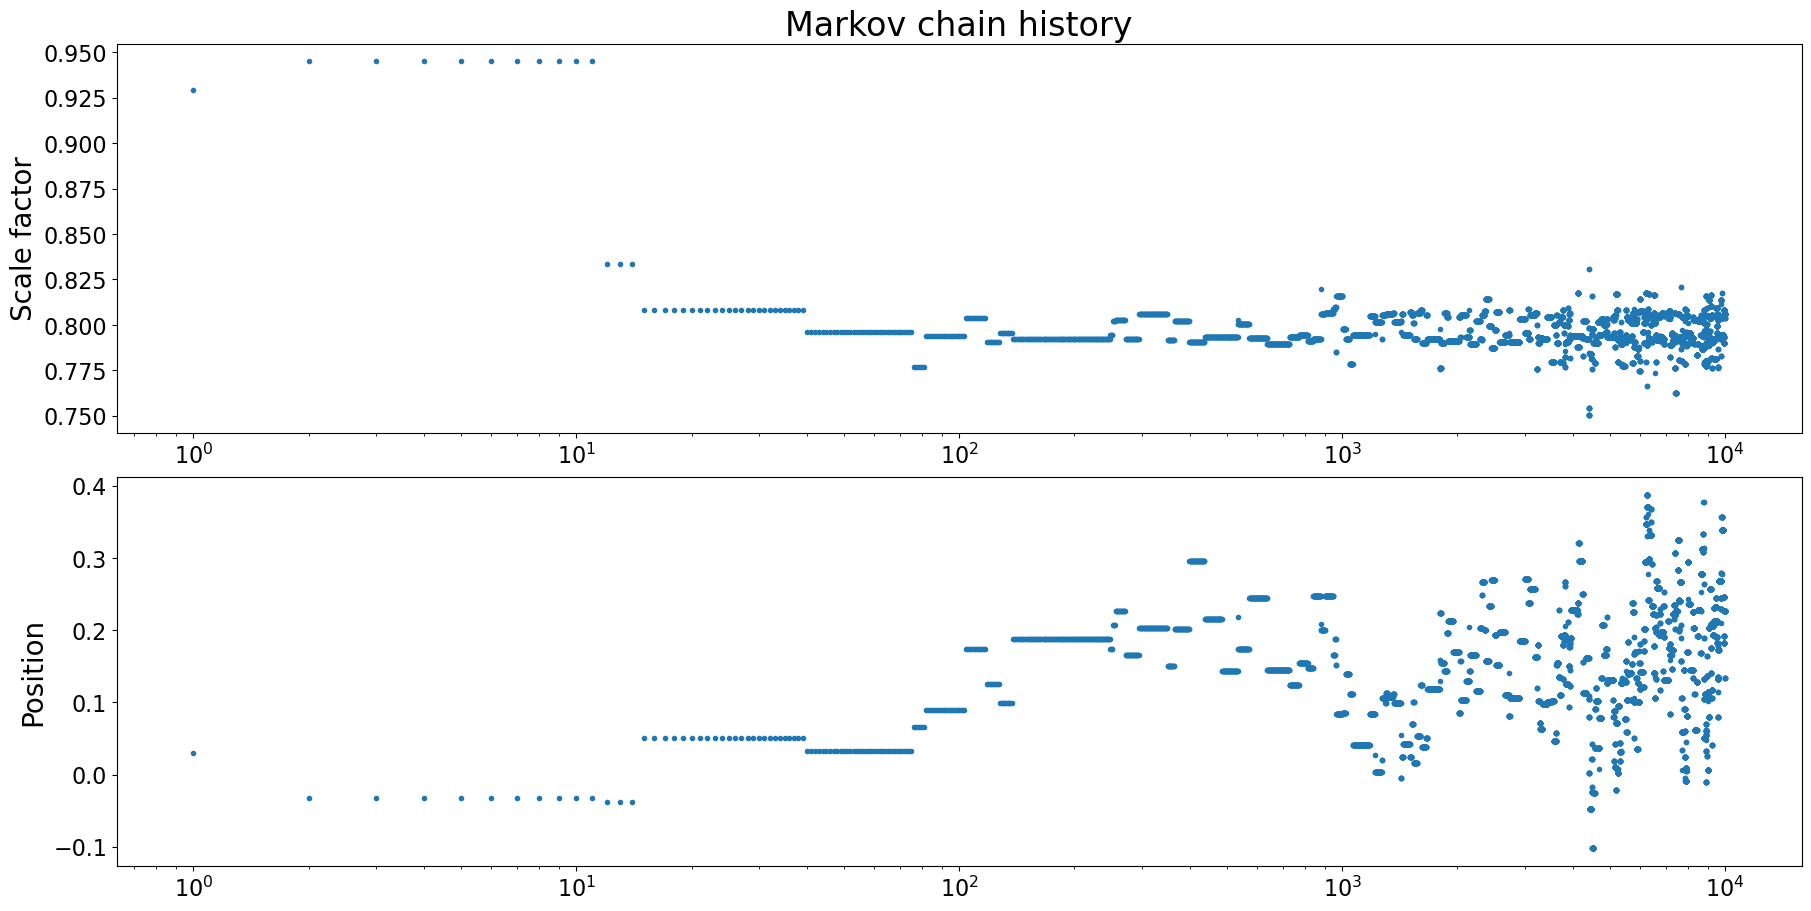

In [8]:
# Already set above
#
# Nmin = 100

thist = np.linspace(1.,Nmc,Nmc)

plt.subplots(2,1,figsize=(18, 9),layout='constrained')

plt.subplot(211)

plt.semilogx(thist,parhist[:,0],'.')

plt.ylabel('Scale factor',size=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Markov chain history",size=24)

plt.subplot(212)

plt.semilogx(thist,parhist[:,1],'.')

#plt.xlabel('Iteration',size=20)
plt.ylabel('Position',size=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.title("Markov chain history",size=24)


fname = '14_mcfit4_'+str(Nmc)+'.png'

plt.savefig(fname,format='png')

plt.show()

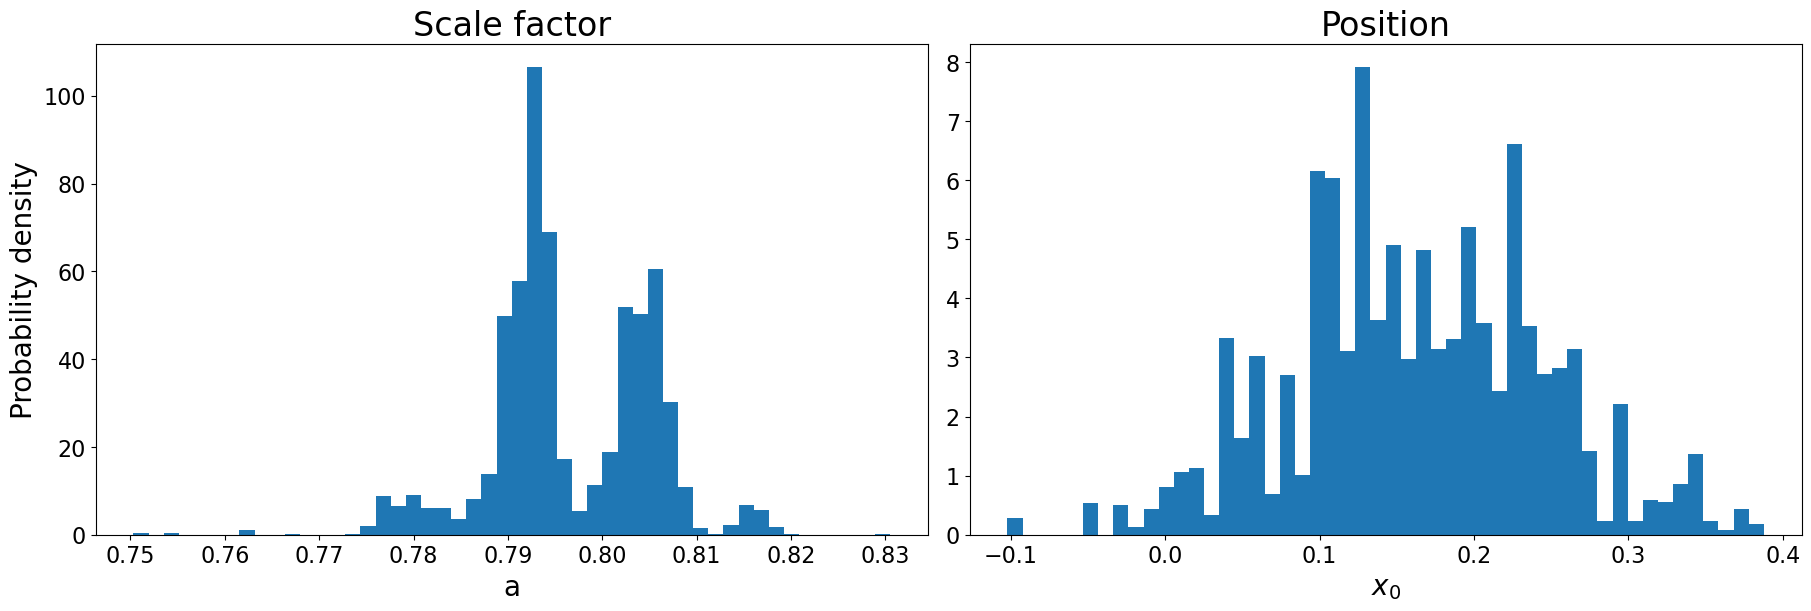

In [9]:
# Already set above
#
# Nmin = 100

plt.subplots(1,2,figsize=(18, 6),layout='constrained')

plt.subplot(121)

plt.hist(parhist[Nmin:,0],density=True,log=False,bins=50)

plt.xlabel('a',size=20)
plt.ylabel('Probability density',size=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Scale factor",size=24)

plt.subplot(122)

plt.hist(parhist[Nmin:,1],density=True,log=False,bins=50)

plt.xlabel(r'$x_{0}$',size=20)
#plt.ylabel('Probability',size=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Position",size=24)

fname = '14_mcfit4_hist_'+str(Nmc)+'.png'

plt.savefig(fname,format='png')

plt.show()

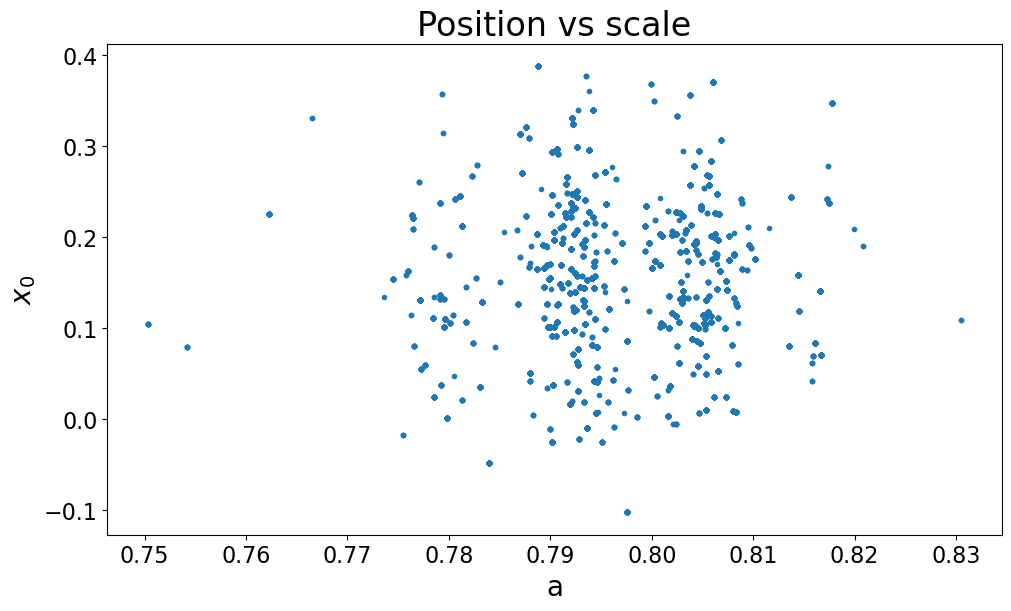

In [10]:
# Already set above
#
# Nmin = 100

plt.figure(figsize=(10,6),layout='constrained')

plt.plot(parhist[Nmin:,0],parhist[Nmin:,1],'.')

plt.ylabel(r'$x_{0}$',size=20)
plt.xlabel('a',size=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Position vs scale",size=24)

fname = '14_mcfit4_hist2_'+str(Nmc)+'.png'

plt.savefig(fname,format='png')

plt.show()